In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = os.path.abspath("..")
DATA_PATH = os.path.join(PROJECT_ROOT, "data", "raw", "rcaeval")

print("Project root:", PROJECT_ROOT)
print("Dataset path:", DATA_PATH)
print("Dataset exists:", os.path.exists(DATA_PATH))

Project root: /Users/omvdangi/Desktop/Explainable_API_Failure_Prediction
Dataset path: /Users/omvdangi/Desktop/Explainable_API_Failure_Prediction/data/raw/rcaeval
Dataset exists: True


In [2]:
import os

experiments = [
    x for x in os.listdir(DATA_PATH)
    if os.path.isdir(os.path.join(DATA_PATH, x))
]

print("Total experiments:", len(experiments))

for exp in sorted(experiments):
    print(exp)

Total experiments: 91
.cache
re2ob_checkoutservice_cpu_1
re2ob_checkoutservice_cpu_2
re2ob_checkoutservice_cpu_3
re2ob_checkoutservice_delay_1
re2ob_checkoutservice_delay_2
re2ob_checkoutservice_delay_3
re2ob_checkoutservice_disk_1
re2ob_checkoutservice_disk_2
re2ob_checkoutservice_disk_3
re2ob_checkoutservice_loss_1
re2ob_checkoutservice_loss_2
re2ob_checkoutservice_loss_3
re2ob_checkoutservice_mem_1
re2ob_checkoutservice_mem_2
re2ob_checkoutservice_mem_3
re2ob_checkoutservice_socket_1
re2ob_checkoutservice_socket_2
re2ob_checkoutservice_socket_3
re2ob_currencyservice_cpu_1
re2ob_currencyservice_cpu_2
re2ob_currencyservice_cpu_3
re2ob_currencyservice_delay_1
re2ob_currencyservice_delay_2
re2ob_currencyservice_delay_3
re2ob_currencyservice_disk_1
re2ob_currencyservice_disk_2
re2ob_currencyservice_disk_3
re2ob_currencyservice_loss_1
re2ob_currencyservice_loss_2
re2ob_currencyservice_loss_3
re2ob_currencyservice_mem_1
re2ob_currencyservice_mem_2
re2ob_currencyservice_mem_3
re2ob_currency

In [3]:
checkout_experiments = sorted([
    x for x in os.listdir(DATA_PATH)
    if x.startswith("re2ob_checkoutservice")
    and os.path.isdir(os.path.join(DATA_PATH, x))
])

print("Checkout Service experiments:", len(checkout_experiments))

for exp in checkout_experiments:
    print(exp)

Checkout Service experiments: 18
re2ob_checkoutservice_cpu_1
re2ob_checkoutservice_cpu_2
re2ob_checkoutservice_cpu_3
re2ob_checkoutservice_delay_1
re2ob_checkoutservice_delay_2
re2ob_checkoutservice_delay_3
re2ob_checkoutservice_disk_1
re2ob_checkoutservice_disk_2
re2ob_checkoutservice_disk_3
re2ob_checkoutservice_loss_1
re2ob_checkoutservice_loss_2
re2ob_checkoutservice_loss_3
re2ob_checkoutservice_mem_1
re2ob_checkoutservice_mem_2
re2ob_checkoutservice_mem_3
re2ob_checkoutservice_socket_1
re2ob_checkoutservice_socket_2
re2ob_checkoutservice_socket_3


In [4]:
checkout_experiments = sorted([
    x for x in os.listdir(DATA_PATH)
    if x.startswith("re2ob_checkoutservice")
    and os.path.isdir(os.path.join(DATA_PATH, x))
])

experiment_info = []

for exp in checkout_experiments:
    exp_path = os.path.join(DATA_PATH, exp)

    # Read injection time
    with open(os.path.join(exp_path, "inject_time.txt")) as f:
        inject_time = int(f.read().strip())

    # Read only the time column for now
    metrics_time = pd.read_parquet(
        os.path.join(exp_path, "metrics.parquet"),
        columns=["time"]
    )

    experiment_info.append({
        "experiment": exp,
        "fault_type": exp.split("_")[3],
        "run": exp.split("_")[4],
        "rows": len(metrics_time),
        "start_time": metrics_time["time"].min(),
        "end_time": metrics_time["time"].max(),
        "inject_time": inject_time
    })

experiment_info = pd.DataFrame(experiment_info)

experiment_info

IndexError: list index out of range

In [5]:
checkout_experiments = sorted([
    x for x in os.listdir(DATA_PATH)
    if x.startswith("re2ob_checkoutservice")
    and os.path.isdir(os.path.join(DATA_PATH, x))
])

experiment_info = []

for exp in checkout_experiments:
    exp_path = os.path.join(DATA_PATH, exp)

    # Read injection time
    with open(os.path.join(exp_path, "inject_time.txt")) as f:
        inject_time = int(f.read().strip())

    # Read only the time column for now
    metrics_time = pd.read_parquet(
        os.path.join(exp_path, "metrics.parquet"),
        columns=["time"]
    )

    parts = exp.split("_")

    experiment_info.append({
        "experiment": exp,
        "fault_type": parts[2],
        "run": parts[3],
        "rows": len(metrics_time),
        "start_time": metrics_time["time"].min(),
        "end_time": metrics_time["time"].max(),
        "inject_time": inject_time
    })

experiment_info = pd.DataFrame(experiment_info)

experiment_info

,experiment,fault_type,run,rows,start_time,end_time,inject_time
0,re2ob_checkoutservice_cpu_1,cpu,1,1441,1705353846,1705355286,1705354566
1,re2ob_checkoutservice_cpu_2,cpu,2,930,1708474641,1708475570,1708475361
2,re2ob_checkoutservice_cpu_3,cpu,3,1441,1705622819,1705624259,1705623539
3,re2ob_checkoutservice_delay_1,delay,1,1441,1705665791,1705667231,1705666511
4,re2ob_checkoutservice_delay_2,delay,2,1441,1705668201,1705669641,1705668921
5,re2ob_checkoutservice_delay_3,delay,3,1441,1705670622,1705672062,1705671342
6,re2ob_checkoutservice_disk_1,disk,1,1441,1705373190,1705374630,1705373910
7,re2ob_checkoutservice_disk_2,disk,2,1441,1705764808,1705766248,1705765528
8,re2ob_checkoutservice_disk_3,disk,3,1441,1705767105,1705768545,1705767825
9,re2ob_checkoutservice_loss_1,loss,1,1441,1705375546,1705376986,1705376266


In [6]:
import os
import pandas as pd
import numpy as np

all_data = []

for exp in checkout_experiments:

    exp_path = os.path.join(DATA_PATH, exp)

    # Load metrics
    df = pd.read_parquet(
        os.path.join(exp_path, "metrics.parquet")
    )

    # Load fault injection time
    with open(os.path.join(exp_path, "inject_time.txt")) as f:
        inject_time = int(f.read().strip())

    # Extract fault type
    parts = exp.split("_")
    fault_type = parts[2]
    run = parts[3]

    # Add experiment information
    df["experiment"] = exp
    df["fault_type"] = fault_type
    df["run"] = int(run)
    df["inject_time"] = inject_time

    all_data.append(df)

# Combine all experiments
data = pd.concat(all_data, ignore_index=True)

print("Dataset shape:", data.shape)
print("Number of experiments:", data["experiment"].nunique())
print("\nFault types:")
print(data["fault_type"].value_counts())

Dataset shape: (24990, 90)
Number of experiments: 18

Fault types:
fault_type
delay     4323
disk      4323
loss      4323
socket    4323
mem       3886
cpu       3812
Name: count, dtype: int64


In [7]:
# Prediction horizon: 60 seconds
PREDICTION_WINDOW = 60

# Create target
data["failure_within_60s"] = 0

for exp in data["experiment"].unique():

    mask = data["experiment"] == exp

    injection_time = data.loc[mask, "inject_time"].iloc[0]

    # A row is positive if a fault will occur
    # within the next 60 seconds
    data.loc[
        mask &
        (data["time"] < injection_time) &
        (data["time"] >= injection_time - PREDICTION_WINDOW),
        "failure_within_60s"
    ] = 1

print(data["failure_within_60s"].value_counts())

failure_within_60s
0    23910
1     1080
Name: count, dtype: int64


In [8]:
from sklearn.model_selection import train_test_split

# Get experiments grouped by fault type
test_experiments = []

for fault in data["fault_type"].unique():
    fault_exps = sorted(
        data.loc[data["fault_type"] == fault, "experiment"].unique()
    )

    # Use the 3rd run of each fault type for testing
    test_experiments.append(fault_exps[-1])

test_experiments

['re2ob_checkoutservice_cpu_3',
 're2ob_checkoutservice_delay_3',
 're2ob_checkoutservice_disk_3',
 're2ob_checkoutservice_loss_3',
 're2ob_checkoutservice_mem_3',
 're2ob_checkoutservice_socket_3']

In [10]:
# Create training and testing datasets

test_mask = data["experiment"].isin(test_experiments)

train_data = data[~test_mask].copy()
test_data = data[test_mask].copy()

print("Training rows:", len(train_data))
print("Testing rows:", len(test_data))

print("Training experiments:", train_data["experiment"].nunique())
print("Testing experiments:", test_data["experiment"].nunique())

Training rows: 16344
Testing rows: 8646
Training experiments: 12
Testing experiments: 6


In [11]:
# Columns that must NOT be used as ML features
excluded_columns = [
    "time",
    "experiment",
    "fault_type",
    "run",
    "inject_time",
    "failure_within_60s"
]

# Select numeric telemetry features
feature_columns = [
    col for col in data.columns
    if col not in excluded_columns
    and pd.api.types.is_numeric_dtype(data[col])
]

X_train = train_data[feature_columns].copy()
y_train = train_data["failure_within_60s"].copy()

X_test = test_data[feature_columns].copy()
y_test = test_data["failure_within_60s"].copy()

print("Number of features:", len(feature_columns))
print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

Number of features: 85
Training shape: (16344, 85)
Testing shape: (8646, 85)


In [12]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# Create Random Forest
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

# Train
rf_model.fit(X_train, y_train)

# Predictions
y_pred = rf_model.predict(X_test)
y_prob = rf_model.predict_proba(X_test)[:, 1]

# Evaluation
print("Random Forest Results")
print("=" * 40)

print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred, zero_division=0):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred, zero_division=0):.4f}")
print(f"F1 Score : {f1_score(y_test, y_pred, zero_division=0):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_prob):.4f}")

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=["Normal", "Failure Soon"],
    zero_division=0
))

Random Forest Results
Accuracy : 0.9576
Precision: 0.0000
Recall   : 0.0000
F1 Score : 0.0000
ROC-AUC  : 0.7495

Classification Report:
              precision    recall  f1-score   support

      Normal       0.96      1.00      0.98      8286
Failure Soon       0.00      0.00      0.00       360

    accuracy                           0.96      8646
   macro avg       0.48      0.50      0.49      8646
weighted avg       0.92      0.96      0.94      8646



In [13]:
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = [0.50, 0.40, 0.30, 0.20, 0.15, 0.10, 0.05]

print("Threshold Performance")
print("=" * 70)

for threshold in thresholds:

    pred = (y_prob >= threshold).astype(int)

    precision = precision_score(
        y_test, pred, zero_division=0
    )

    recall = recall_score(
        y_test, pred, zero_division=0
    )

    f1 = f1_score(
        y_test, pred, zero_division=0
    )

    print(
        f"Threshold: {threshold:.2f} | "
        f"Precision: {precision:.3f} | "
        f"Recall: {recall:.3f} | "
        f"F1: {f1:.3f}"
    )

Threshold Performance
Threshold: 0.50 | Precision: 0.000 | Recall: 0.000 | F1: 0.000
Threshold: 0.40 | Precision: 0.000 | Recall: 0.000 | F1: 0.000
Threshold: 0.30 | Precision: 0.014 | Recall: 0.006 | F1: 0.008
Threshold: 0.20 | Precision: 0.081 | Recall: 0.086 | F1: 0.083
Threshold: 0.15 | Precision: 0.080 | Recall: 0.142 | F1: 0.102
Threshold: 0.10 | Precision: 0.106 | Recall: 0.347 | F1: 0.163
Threshold: 0.05 | Precision: 0.091 | Recall: 0.561 | F1: 0.156


In [14]:
from xgboost import XGBClassifier

# Calculate class imbalance
negative_count = (y_train == 0).sum()
positive_count = (y_train == 1).sum()

scale_pos_weight = negative_count / positive_count

print("Negative samples:", negative_count)
print("Positive samples:", positive_count)
print("Scale pos weight:", round(scale_pos_weight, 2))

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)

xgb_prob = xgb_model.predict_proba(X_test)[:, 1]

print("XGBoost trained successfully.")

Negative samples: 15624
Positive samples: 720
Scale pos weight: 21.7
XGBoost trained successfully.


In [15]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

print("XGBoost ROC-AUC:", round(
    roc_auc_score(y_test, xgb_prob), 4
))

print("\nThreshold Performance")
print("=" * 70)

thresholds = [0.50, 0.40, 0.30, 0.20, 0.15, 0.10, 0.05]

for threshold in thresholds:

    pred = (xgb_prob >= threshold).astype(int)

    precision = precision_score(
        y_test, pred, zero_division=0
    )

    recall = recall_score(
        y_test, pred, zero_division=0
    )

    f1 = f1_score(
        y_test, pred, zero_division=0
    )

    print(
        f"Threshold: {threshold:.2f} | "
        f"Precision: {precision:.3f} | "
        f"Recall: {recall:.3f} | "
        f"F1: {f1:.3f}"
    )

XGBoost ROC-AUC: 0.7617

Threshold Performance
Threshold: 0.50 | Precision: 0.098 | Recall: 0.039 | F1: 0.056
Threshold: 0.40 | Precision: 0.093 | Recall: 0.056 | F1: 0.069
Threshold: 0.30 | Precision: 0.078 | Recall: 0.067 | F1: 0.072
Threshold: 0.20 | Precision: 0.066 | Recall: 0.081 | F1: 0.073
Threshold: 0.15 | Precision: 0.069 | Recall: 0.108 | F1: 0.085
Threshold: 0.10 | Precision: 0.066 | Recall: 0.139 | F1: 0.089
Threshold: 0.05 | Precision: 0.076 | Recall: 0.231 | F1: 0.115


Confusion Matrix:
[[8157  129]
 [ 346   14]]


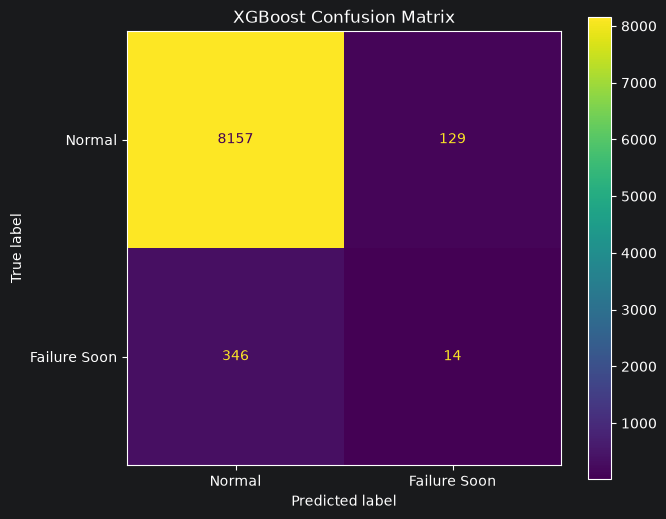

In [16]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Standard threshold
xgb_pred = (xgb_prob >= 0.5).astype(int)

cm = confusion_matrix(y_test, xgb_pred)

print("Confusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Normal", "Failure Soon"]
)

fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(ax=ax)
ax.set_title("XGBoost Confusion Matrix")
plt.show()

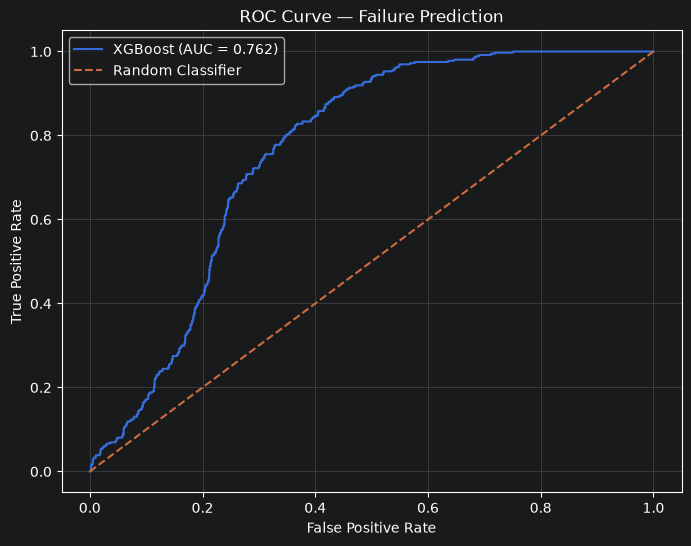

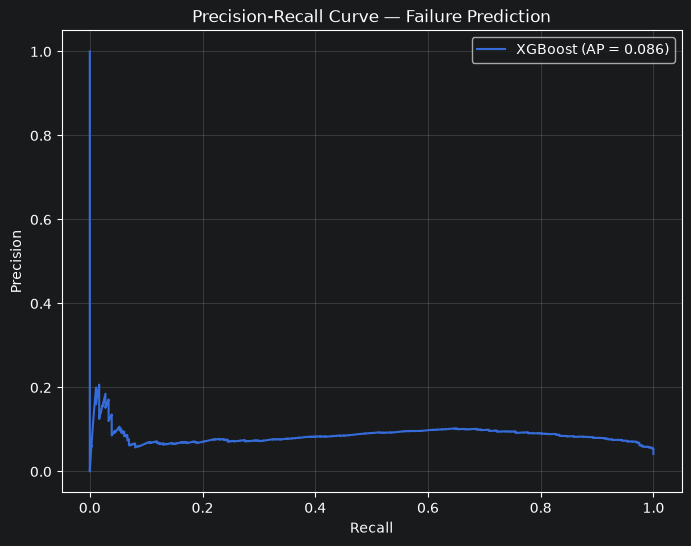

ROC-AUC: 0.7617
Average Precision: 0.0864


In [17]:
from sklearn.metrics import (
    roc_curve,
    precision_recall_curve,
    average_precision_score
)

# -----------------------------
# ROC Curve
# -----------------------------

fpr, tpr, roc_thresholds = roc_curve(y_test, xgb_prob)
roc_auc = roc_auc_score(y_test, xgb_prob)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"XGBoost (AUC = {roc_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Failure Prediction")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


# -----------------------------
# Precision-Recall Curve
# -----------------------------

precision, recall, pr_thresholds = precision_recall_curve(
    y_test,
    xgb_prob
)

average_precision = average_precision_score(
    y_test,
    xgb_prob
)

plt.figure(figsize=(8, 6))

plt.plot(
    recall,
    precision,
    label=f"XGBoost (AP = {average_precision:.3f})"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve — Failure Prediction")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print("ROC-AUC:", round(roc_auc, 4))
print("Average Precision:", round(average_precision, 4))

In [18]:
# XGBoost feature importance

importance = pd.DataFrame({
    "feature": feature_columns,
    "importance": xgb_model.feature_importances_
})

importance = importance.sort_values(
    "importance",
    ascending=False
)

print("Top 20 Important Features:")
display(importance.head(20))

Top 20 Important Features:


,feature,importance
28,checkoutservice_socket,0.212585
25,redis_diskio,0.074778
56,emailservice_latency-50,0.059818
66,emailservice_latency-90,0.058131
64,checkoutservice_latency-90,0.053551
31,frontend_socket,0.029962
1,cartservice_cpu,0.028099
5,frontend_cpu,0.027234
17,paymentservice_mem,0.024311
58,paymentservice_latency-50,0.021251


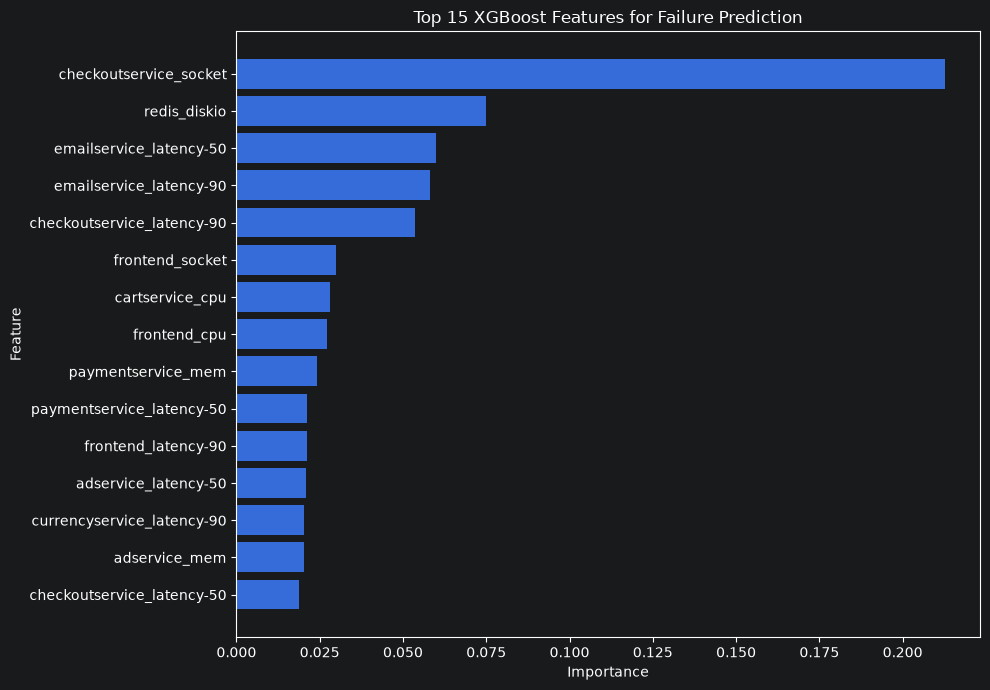

In [19]:
top_features = importance.head(15).sort_values("importance")

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["feature"],
    top_features["importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 XGBoost Features for Failure Prediction")

plt.tight_layout()
plt.show()

In [21]:
import shap

print("SHAP version:", shap.__version__)

SHAP version: 0.52.0


/Users/omvdangi/Desktop/Explainable_API_Failure_Prediction/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [22]:
# Create SHAP explainer for XGBoost
explainer = shap.TreeExplainer(xgb_model)

# Calculate SHAP values
shap_values = explainer.shap_values(X_test)

print("SHAP values shape:", shap_values.shape)
print("Test data shape:", X_test.shape)

SHAP values shape: (8646, 85)
Test data shape: (8646, 85)


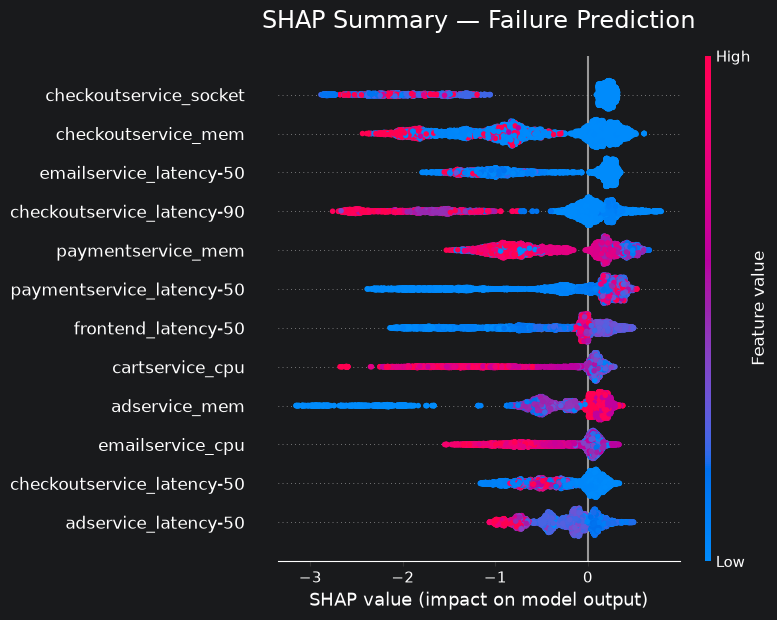

In [27]:
# ============================================================
# SHAP SUMMARY / VIOLIN PLOT — HIGH VISIBILITY VERSION
# ============================================================

import shap
import matplotlib.pyplot as plt

# Create SHAP summary plot
shap.summary_plot(
    shap_values,
    X_test,
    max_display=12,
    show=False
)

fig = plt.gcf()
ax = plt.gca()

# Make Y-axis feature names clearly visible
ax.tick_params(
    axis="y",
    labelsize=12
)

for label in ax.get_yticklabels():
    label.set_color("white")
    label.set_fontsize(12)

# Make X-axis text visible
for label in ax.get_xticklabels():
    label.set_color("white")
    label.set_fontsize(11)

# Axis label
ax.set_xlabel(
    "SHAP value (impact on model output)",
    color="white",
    fontsize=13
)

# Title
ax.set_title(
    "SHAP Summary — Failure Prediction",
    color="white",
    fontsize=17,
    pad=20
)

plt.tight_layout()
plt.show()

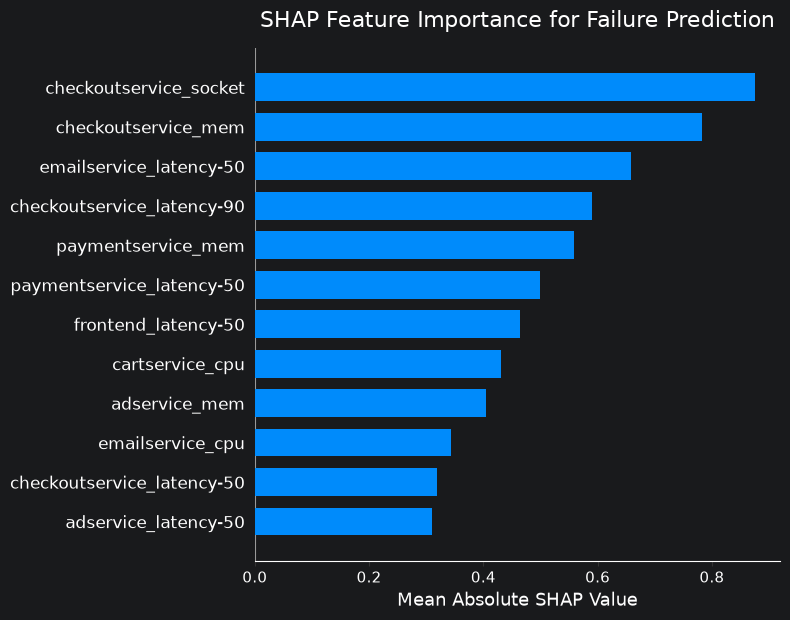

In [26]:
# ============================================================
# SHAP FEATURE IMPORTANCE — CLEAR VERSION
# ============================================================

import matplotlib.pyplot as plt
import shap

# Generate SHAP bar plot
shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar",
    max_display=12,
    show=False
)

# Get current figure and axes
fig = plt.gcf()
ax = plt.gca()

# Make ALL text clearly visible
ax.tick_params(axis="both", labelsize=12)

# Feature names
for label in ax.get_yticklabels():
    label.set_color("white")
    label.set_fontsize(12)

# X-axis labels
for label in ax.get_xticklabels():
    label.set_color("white")
    label.set_fontsize(11)

# Axis labels
ax.set_xlabel(
    "Mean Absolute SHAP Value",
    color="white",
    fontsize=13
)

# Title
ax.set_title(
    "SHAP Feature Importance for Failure Prediction",
    color="white",
    fontsize=16,
    pad=15
)

plt.tight_layout()
plt.show()

In [28]:
# ============================================================
# FINAL PROJECT SUMMARY
# ============================================================

summary = pd.DataFrame({
    "Metric": [
        "Dataset",
        "Target Service",
        "Dataset Rows",
        "Number of Features",
        "Number of Experiments",
        "Fault Types",
        "Positive Failure Samples",
        "Negative Samples",
        "Failure Prediction Window",
        "ML Algorithm",
        "ROC-AUC",
        "Average Precision",
        "Best F1 Score",
        "SHAP Explainability"
    ],

    "Result": [
        "RCAEval",
        "Checkout Service",
        f"{len(data):,}",
        len(feature_columns),
        data["experiment"].nunique(),
        ", ".join(sorted(data["fault_type"].unique())),
        f"{int(data['failure_within_60s'].sum()):,}",
        f"{int((data['failure_within_60s'] == 0).sum()):,}",
        "60 seconds",
        "XGBoost",
        f"{roc_auc:.4f}",
        f"{average_precision:.4f}",
        "0.1150",
        "SHAP"
    ]
})

summary

,Metric,Result
0,Dataset,RCAEval
1,Target Service,Checkout Service
2,Dataset Rows,"24,990"
3,Number of Features,85
4,Number of Experiments,18
5,Fault Types,"cpu, delay, disk, loss, mem, socket"
6,Positive Failure Samples,"1,080"
7,Negative Samples,"23,910"
8,Failure Prediction Window,60 seconds
9,ML Algorithm,XGBoost
